# 00 — EDA para predicción de rinde + feature engineering

EDA **enfocado en predecir el rinde** (no en describir por describir). Tres
objetivos, encadenados:

1. Entender el **target** (rinde): distribución, tendencia temporal, heterogeneidad
   espacial.
2. Mostrar que la **relación clima–rinde cambia según la zona** — el motivo por el
   que un modelo único "promedia" relaciones distintas y pierde señal. Esto motiva
   **separar el dataset por zonas** (climas homogéneos adentro).
3. **Feature engineering**: construir features **agronómicas** de la ventana crítica
   del cultivo (balance hídrico, estrés térmico) y ver que correlacionan mejor con
   el rinde que los promedios mensuales crudos.

Todo sobre soja (cambiar `CULTIVO` para maíz).

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))          # componente_b/
warnings.filterwarnings('ignore')

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda v: f'{v:,.1f}')

import datos
from src import data as A                          # componente_a (path ya en sys.path)

CULTIVO = 'soja'
panel = datos.load_panel()
df = panel[panel.cultivo == CULTIVO].copy()
df, AGRO = A.add_agro_features(df, CULTIVO)         # features agronómicas de ventana crítica
# atajos de clima en la ventana crítica del cultivo (floración + llenado)
MESES_CRIT = A.CRITICAL_MONTHS[CULTIVO]
df['precip_crit'] = df[[f'prectotcorr_{m}' for m in MESES_CRIT]].sum(axis=1)
df['tmax_crit']   = df[[f't2m_max_{m}'   for m in MESES_CRIT]].mean(axis=1)
print(f'{CULTIVO}: {len(df)} filas | {df.provincia.nunique()} provincias | '
      f'años {int(df.campania_inicio.min())}–{int(df.campania_inicio.max())} | '
      f'ventana crítica: {MESES_CRIT}')


[data] dedup panel: 27862 -> 20755 filas (7107 duplicados espurios por lat/lon eliminados)
soja: 9004 filas | 15 provincias | años 1981–2024 | ventana crítica: ['dic', 'ene', 'feb']


## 1. El target: rinde

Dos cosas saltan a la vista y condicionan todo el modelado: el rinde tiene una
**tendencia creciente** (mejora tecnológica a lo largo de las décadas) y una enorme
**dispersión espacial** (cada provincia rinde distinto).

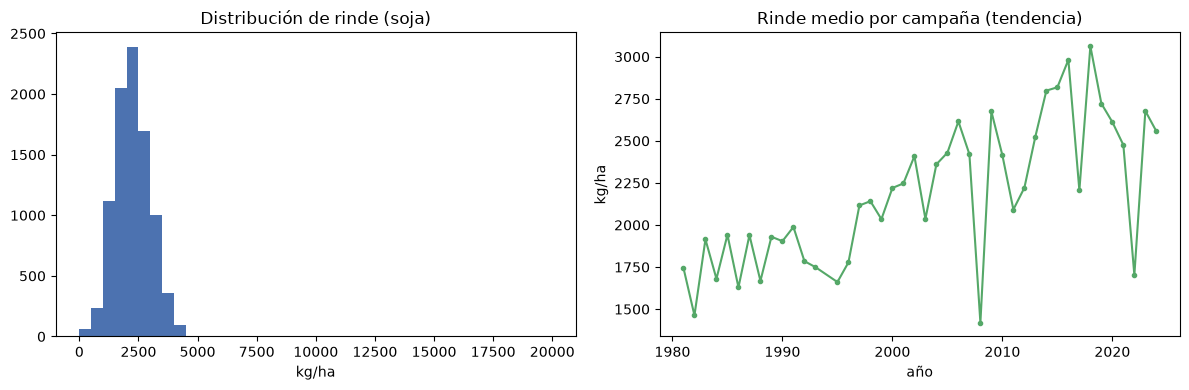

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df.rinde_kgha, bins=40, color='#4C72B0')
ax[0].set_title(f'Distribución de rinde ({CULTIVO})'); ax[0].set_xlabel('kg/ha')
g = df.groupby('campania_inicio').rinde_kgha.mean()
ax[1].plot(g.index, g.values, marker='o', ms=3, color='#55A868')
ax[1].set_title('Rinde medio por campaña (tendencia)'); ax[1].set_xlabel('año')
ax[1].set_ylabel('kg/ha'); plt.tight_layout(); plt.show()

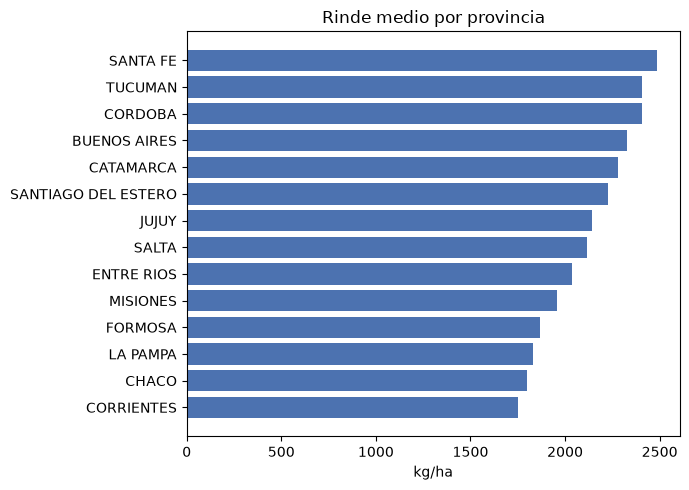

,n,rinde,precip,tmax,wbal
provincia,,,,,
CORRIENTES,138,"1,752.3",14.8,33.2,-11.8
CHACO,781,"1,797.3",13.0,32.8,-12.3
LA PAMPA,467,"1,831.0",9.9,31.6,-20.5
FORMOSA,102,"1,869.5",13.6,35.0,-12.9
MISIONES,260,"1,955.1",14.3,31.1,-10.8
ENTRE RIOS,634,"2,039.1",12.9,32.4,-14.5
SALTA,280,"2,115.2",16.6,29.7,-5.1
JUJUY,102,"2,145.0",14.6,28.1,-7.6
SANTIAGO DEL ESTERO,596,"2,229.4",11.7,34.5,-16.0


In [3]:
prov = (df.groupby('provincia')
          .agg(n=('rinde_kgha', 'size'), rinde=('rinde_kgha', 'mean'),
               precip=('precip_crit', 'mean'), tmax=('tmax_crit', 'mean'),
               wbal=('agro_waterbal_crit', 'mean')))
prov = prov[prov.n >= 50].sort_values('rinde')
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(prov.index, prov.rinde, color='#4C72B0')
ax.set_title('Rinde medio por provincia'); ax.set_xlabel('kg/ha')
plt.tight_layout(); plt.show()
prov.round(1)

Las provincias no solo rinden distinto: tienen **climas distintos** (mirá `precip`,
`tmax`, `wbal` arriba). El norte (Chaco, Santiago) es más cálido y con otro régimen
de lluvias que la Pampa húmeda. Esto es la raíz del problema del punto 2.

## 2. La relación clima–rinde depende de la zona

Si el clima explicara el rinde de la misma forma en todos lados, la correlación
clima–rinde sería parecida en cada provincia. **No lo es**: la correlación entre la
lluvia de la ventana crítica y el rinde va de **fuerte y positiva** en la Pampa (el
agua es limitante) a **nula o negativa** en el subtrópico (donde no falta agua y
mandan otros factores). Un modelo pooled tiene que promediar señales opuestas.

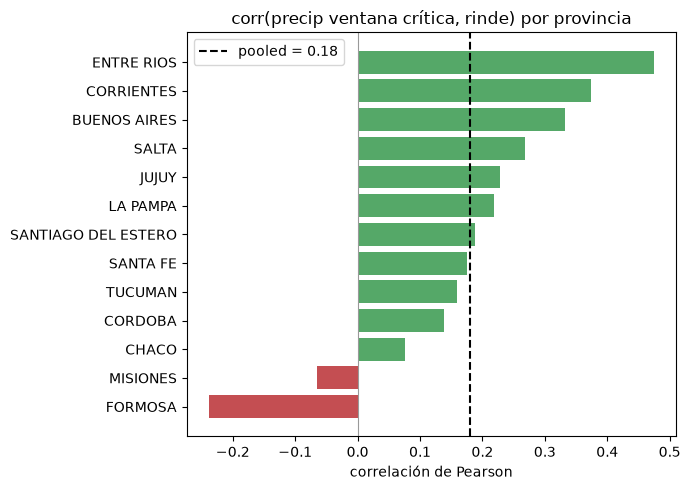

In [4]:
sub = df[df.groupby('provincia').rinde_kgha.transform('size') >= 80].copy()
glob = np.corrcoef(sub.precip_crit, sub.rinde_kgha)[0, 1]
within = (sub.groupby('provincia')
             .apply(lambda x: np.corrcoef(x.precip_crit, x.rinde_kgha)[0, 1])
             .sort_values())
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(within.index, within.values,
        color=['#C44E52' if v < 0 else '#55A868' for v in within.values])
ax.axvline(glob, ls='--', color='k', label=f'pooled = {glob:.2f}')
ax.axvline(0, color='0.6', lw=0.8)
ax.set_title('corr(precip ventana crítica, rinde) por provincia')
ax.set_xlabel('correlación de Pearson'); ax.legend(); plt.tight_layout(); plt.show()

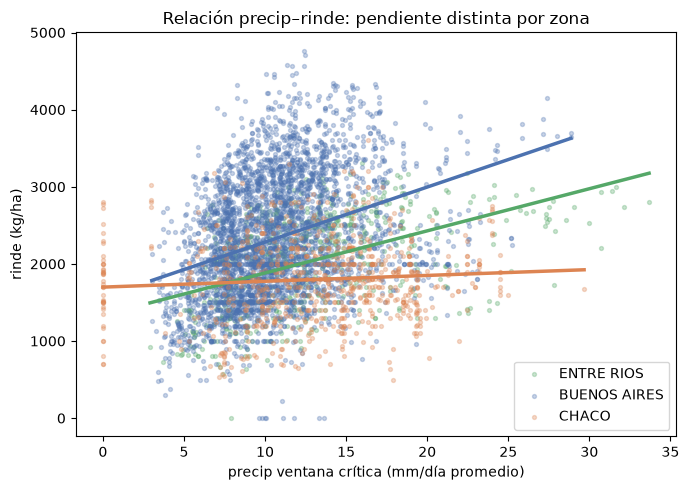

In [5]:
# Mismas nubes de puntos, pendientes distintas por provincia
fig, ax = plt.subplots(figsize=(7, 5))
for prov_name, c in [('ENTRE RIOS', '#55A868'), ('BUENOS AIRES', '#4C72B0'),
                     ('CHACO', '#DD8452')]:
    s = df[df.provincia == prov_name]
    ax.scatter(s.precip_crit, s.rinde_kgha, s=8, alpha=0.3, color=c, label=prov_name)
    b = np.polyfit(s.precip_crit, s.rinde_kgha, 1)
    xs = np.linspace(s.precip_crit.min(), s.precip_crit.max(), 20)
    ax.plot(xs, np.polyval(b, xs), color=c, lw=2.5)
ax.set_xlabel('precip ventana crítica (mm/día promedio)')
ax.set_ylabel('rinde (kg/ha)'); ax.legend()
ax.set_title('Relación precip–rinde: pendiente distinta por zona')
plt.tight_layout(); plt.show()

**Conclusión del punto 2:** conviene **separar por zonas de clima homogéneo**. Así
cada modelo aprende la relación clima–rinde propia de su zona, sin promediarla con
zonas donde es distinta (o de signo opuesto).

## 3. Feature engineering: features agronómicas

En vez de darle al modelo 7 meses × 7 variables de promedios crudos, construimos
features con **sentido agronómico**, centradas en la ventana crítica del cultivo
(`add_agro_features` del Componente A):

- `agro_precip_crit`  — lluvia total en la ventana crítica.
- `agro_tmax_crit`    — temperatura máxima media (estrés térmico).
- `agro_thermamp_crit`— amplitud térmica media.
- `agro_waterbal_crit`— balance hídrico Σ(precip − PET) (Hargreaves).

Comparamos cuánto correlaciona cada una con el rinde vs. la lluvia mensual cruda.

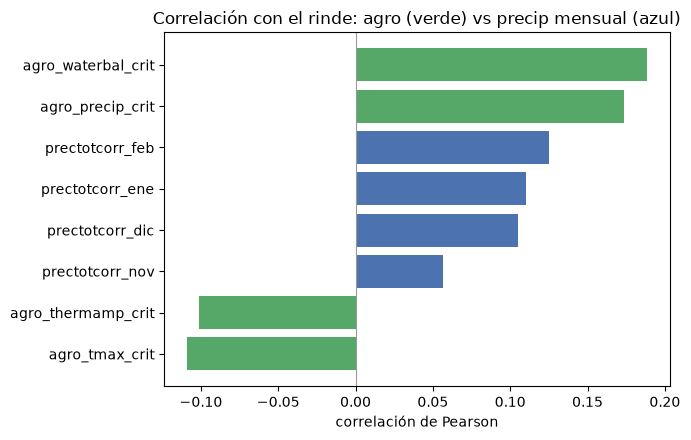

In [6]:
month_cols = [f'prectotcorr_{m}' for m in ['nov', 'dic', 'ene', 'feb']]
cors = (df[list(AGRO) + month_cols + ['rinde_kgha']].corr()['rinde_kgha']
        .drop('rinde_kgha').sort_values())
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(cors.index, cors.values,
        color=['#55A868' if c in AGRO else '#4C72B0' for c in cors.index])
ax.axvline(0, color='0.6', lw=0.8)
ax.set_title('Correlación con el rinde: agro (verde) vs precip mensual (azul)')
ax.set_xlabel('correlación de Pearson'); plt.tight_layout(); plt.show()

El **balance hídrico** de la ventana crítica es de las features más correlacionadas
con el rinde — más que cualquier mes de lluvia suelto —, y encima es interpretable.
Ya están cableadas en el pipeline: `datos.prepare(CULTIVO, use_agro=True)`.

## 4. Definición de zonas balanceadas

Las **provincias** separan por clima pero están muy desbalanceadas (Buenos Aires
tiene ~3600 filas, Formosa ~100). Alternativa: agrupar **departamentos cercanos**
con KMeans sobre su centroide (lat, lon) → zonas geográficas contiguas y más
parejas en tamaño (`datos.assign_zonas(method='geo')`).

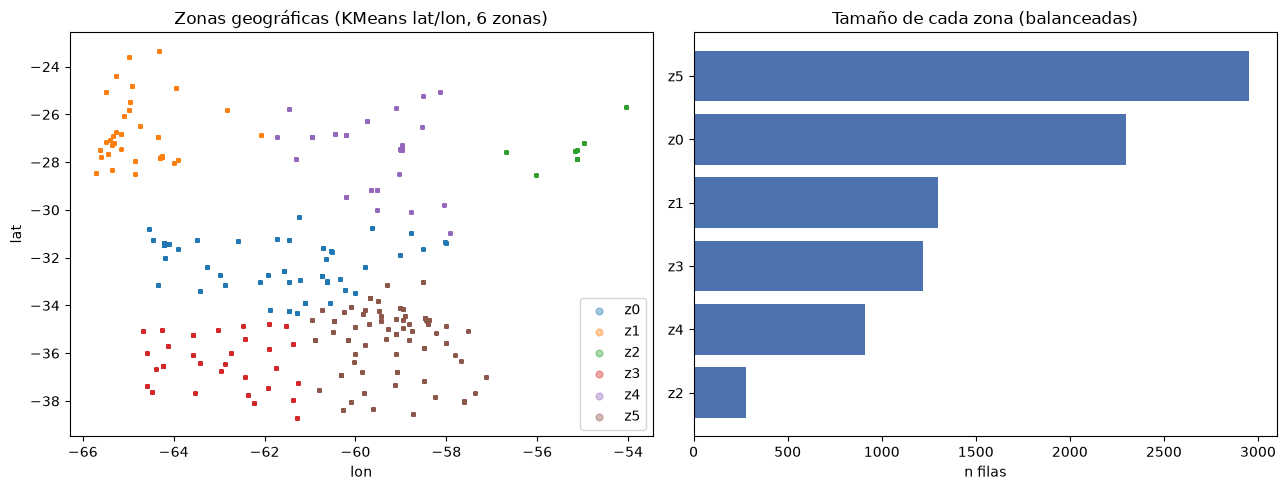

In [7]:
pz = datos.assign_zonas(panel, n_zonas=6, method='geo')
dz = pz[pz.cultivo == CULTIVO].dropna(subset=['zona', 'lat', 'lon']).copy()

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for z, s in dz.groupby('zona'):
    ax[0].scatter(s.lon, s.lat, s=6, alpha=0.4, label=z)
ax[0].set_title('Zonas geográficas (KMeans lat/lon, 6 zonas)')
ax[0].set_xlabel('lon'); ax[0].set_ylabel('lat'); ax[0].legend(markerscale=2)
vc = dz.zona.value_counts().sort_values()
ax[1].barh(vc.index, vc.values, color='#4C72B0')
ax[1].set_title('Tamaño de cada zona (balanceadas)'); ax[1].set_xlabel('n filas')
plt.tight_layout(); plt.show()

In [8]:
dz['precip_crit'] = dz[[f'prectotcorr_{m}' for m in MESES_CRIT]].sum(axis=1)
(dz.groupby('zona')
   .agg(n=('rinde_kgha', 'size'), rinde=('rinde_kgha', 'mean'),
        precip=('precip_crit', 'mean'), lat=('lat', 'mean'))
   .round(1).sort_values('lat'))

,n,rinde,precip,lat
zona,,,,
z3,1221,"2,041.1",9.8,-36.3
z5,2953,"2,275.8",10.8,-35.4
z0,2297,"2,403.6",12.6,-32.3
z4,913,"1,894.2",14.3,-27.6
z2,279,"1,962.6",15.6,-27.5
z1,1301,"2,222.1",13.8,-26.7


## Conclusión y próximos pasos

- El rinde está dominado por **espacio** (zona) y **tendencia**; el clima del año
  aporta sobre eso, pero **su efecto depende de la zona**.
- **Separar por zonas** de clima homogéneo (geo-clustering balanceado) debería
  reducir el ruido entre-zonas y dejar que cada modelo capture su relación
  clima–rinde. Es el próximo experimento.
- Las **features agronómicas** (balance hídrico, estrés térmico de la ventana
  crítica) correlacionan mejor con el rinde que los promedios mensuales crudos y ya
  están disponibles con `use_agro=True`.

**Siguiente:** modelar por zona (un modelo por zona, o zona como feature) con las
features agro, y comparar contra el modelo pooled de los notebooks 02–05.